In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('./data/santander_train.csv', encoding='latin-1')
print(df.shape)
df.head()

(76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [221]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [220]:
print(df['TARGET'].value_counts())

TARGET
0    73012
1     3008
Name: count, dtype: int64


In [222]:
unsatified_cnt = df[df['TARGET'] == 1].TARGET.count()
total_cnt = df.TARGET.count()
print(unsatified_cnt, total_cnt)
print(unsatified_cnt / total_cnt)

3008 76020
0.0395685345961589


In [223]:
df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [224]:
df['var3'].value_counts()

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
           ...  
 63            1
 194           1
 40            1
 57            1
 87            1
Name: count, Length: 208, dtype: int64

In [225]:
df['var3'] = df['var3'].replace(-999999, 2)
df = df.drop('ID', axis=1)

In [226]:
df.head()

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [227]:
df['var3'].value_counts()

var3
2      74281
8        138
9        110
3        108
1        105
       ...  
63         1
194        1
40         1
57         1
87         1
Name: count, Length: 207, dtype: int64

In [228]:
X_features = df.iloc[:,:-1]
y_label = df.iloc[:,-1]

In [229]:
from sklearn.model_selection import train_test_split, KFold

X_train, X_test, y_train, y_test = train_test_split(X_features, y_label,
                                                    test_size=0.2, random_state=42)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                                            test_size=0.3, random_state=42)

In [ ]:
# -*- coding: utf-8 -*-
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='auc'
)

xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)]);

[0]	validation_0-auc:0.84615	validation_1-auc:0.81461
[1]	validation_0-auc:0.84937	validation_1-auc:0.81892
[2]	validation_0-auc:0.85131	validation_1-auc:0.82131
[3]	validation_0-auc:0.85518	validation_1-auc:0.82544
[4]	validation_0-auc:0.85553	validation_1-auc:0.82581
[5]	validation_0-auc:0.85651	validation_1-auc:0.82656
[6]	validation_0-auc:0.85743	validation_1-auc:0.82688
[7]	validation_0-auc:0.85859	validation_1-auc:0.82639
[8]	validation_0-auc:0.86034	validation_1-auc:0.82834
[9]	validation_0-auc:0.86245	validation_1-auc:0.82916
[10]	validation_0-auc:0.86366	validation_1-auc:0.82955
[11]	validation_0-auc:0.86490	validation_1-auc:0.83048
[12]	validation_0-auc:0.86563	validation_1-auc:0.83017
[13]	validation_0-auc:0.86649	validation_1-auc:0.83034
[14]	validation_0-auc:0.86706	validation_1-auc:0.83046
[15]	validation_0-auc:0.86778	validation_1-auc:0.83071
[16]	validation_0-auc:0.86838	validation_1-auc:0.83139
[17]	validation_0-auc:0.86883	validation_1-auc:0.83164
[18]	validation_0-au

In [ ]:
xgb_roc_auc = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print(xgb_roc_auc)

0.8411168416159174


In [ ]:
from hyperopt import hp

xgb_search_space = {
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'colsample_bytree': hp.quniform('colsample_bytree', 0.5, 0.95, 0.05),
    'learning_rate': hp.quniform('learning_rate', 0.01, 0.2, 0.01)
}

In [ ]:
from sklearn.metrics import roc_auc_score

def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators=400,
                            max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                            early_stopping_rounds=30,
                            eval_metric='auc')

    roc_auc_lists = []

    kf = KFold(n_splits = 3)

    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        xgb_clf.fit(X_tr, y_tr,
                    eval_set=[(X_tr, y_tr), (X_val, y_val)])

        score = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_lists.append(score)

    return -1 * np.mean(roc_auc_lists)

In [ ]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trials,
            rstate=np.random.default_rng(seed=30))

print(best)

[0]	validation_0-auc:0.84793	validation_1-auc:0.80610 
[1]	validation_0-auc:0.85144	validation_1-auc:0.80761 
[2]	validation_0-auc:0.85431	validation_1-auc:0.81206 
[3]	validation_0-auc:0.85713	validation_1-auc:0.81399 
[4]	validation_0-auc:0.86015	validation_1-auc:0.81700 
[5]	validation_0-auc:0.86061	validation_1-auc:0.81807 
[6]	validation_0-auc:0.86185	validation_1-auc:0.81783 
[7]	validation_0-auc:0.86561	validation_1-auc:0.81885 
[8]	validation_0-auc:0.86733	validation_1-auc:0.81965 
[9]	validation_0-auc:0.86980	validation_1-auc:0.82132 
[10]	validation_0-auc:0.87090	validation_1-auc:0.81918
[11]	validation_0-auc:0.87192	validation_1-auc:0.81774
[12]	validation_0-auc:0.87310	validation_1-auc:0.81819
[13]	validation_0-auc:0.87415	validation_1-auc:0.81875
[14]	validation_0-auc:0.87482	validation_1-auc:0.81985
[15]	validation_0-auc:0.87602	validation_1-auc:0.81961
[16]	validation_0-auc:0.87702	validation_1-auc:0.82023
[17]	validation_0-auc:0.87786	validation_1-auc:0.82169
[18]	valid

In [ ]:
xgb_clf = XGBClassifier(n_estimators=400,
                        learning_rate=round(best['learning_rate'], 5),
                        max_depth=int(best['max_depth']),
                        min_child_weight=int(best['min_child_weight']),
                        colsample_bytree=round(best['colsample_bytree'],5 ),
                        early_stopping_rounds=50,
                        eval_metric='auc')
xgb_clf.fit(X_tr, y_tr,
            eval_set = [(X_tr,y_tr),(X_val,y_val)])

xgb_roc_auc = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print(xgb_roc_auc)

[0]	validation_0-auc:0.84118	validation_1-auc:0.81861
[1]	validation_0-auc:0.84428	validation_1-auc:0.82321
[2]	validation_0-auc:0.84812	validation_1-auc:0.82503
[3]	validation_0-auc:0.85012	validation_1-auc:0.82573
[4]	validation_0-auc:0.85268	validation_1-auc:0.82811
[5]	validation_0-auc:0.85480	validation_1-auc:0.82981
[6]	validation_0-auc:0.85762	validation_1-auc:0.83139
[7]	validation_0-auc:0.85848	validation_1-auc:0.83133
[8]	validation_0-auc:0.85988	validation_1-auc:0.83166
[9]	validation_0-auc:0.86095	validation_1-auc:0.83324
[10]	validation_0-auc:0.86192	validation_1-auc:0.83318
[11]	validation_0-auc:0.86216	validation_1-auc:0.83256
[12]	validation_0-auc:0.86302	validation_1-auc:0.83290
[13]	validation_0-auc:0.86476	validation_1-auc:0.83282
[14]	validation_0-auc:0.86548	validation_1-auc:0.83358
[15]	validation_0-auc:0.86612	validation_1-auc:0.83383
[16]	validation_0-auc:0.86722	validation_1-auc:0.83451
[17]	validation_0-auc:0.86751	validation_1-auc:0.83473
[18]	validation_0-au

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

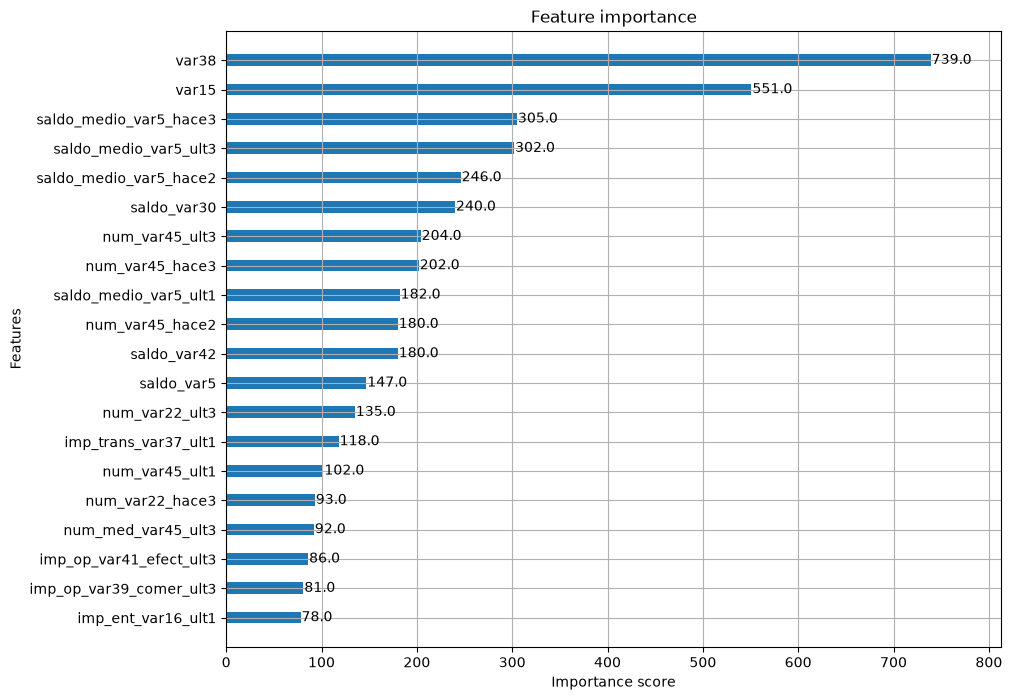

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf, ax=ax, max_num_features=20, height=0.4)

In [215]:
from lightgbm import LGBMClassifier


lgbm_clf = LGBMClassifier(n_estimators=500)
eval_set = [(X_tr, y_tr), (X_val, y_val)]
lgbm_clf.fit(X_tr, y_tr,
             eval_metric='auc',
             eval_set=eval_set)

lgbm_roc_auc=roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,1])

print(lgbm_roc_auc)

0.8018817818063989


In [214]:
lgbm_search_space = {
    'num_leaves': hp.quniform('num_leaves', 32, 64, 1),
    'max_depth': hp.quniform('max_depth', 100, 160, 1),
    'min_child_samples': hp.quniform('min_child_samples', 60, 100, 1),
    'subsample': hp.quniform('subsample', 0.7, 1, 0.1),
    'learning_rate': hp.quniform('learning_rate', 0.01, 0.2, 0.01)
}

In [231]:
def objective_func(search_space):
    lgbm_clf = LGBMClassifier(n_estimators=100,
                              num_leaves=int(search_space['num_leaves']),
                              max_depth=int(search_space['max_depth']),
                              min_child_samples=int(search_space['min_child_samples']),
                              subsample=search_space['subsample'],
                              learning_rate=search_space['learning_rate'],
                              early_stopping_rounds=30,
                              eval_metric='auc',)

    roc_auc_lists = []

    kf = KFold(n_splits=3)

    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        lgbm_clf.fit(X_tr, y_tr,
                     eval_set=[(X_tr, y_tr), (X_val, y_val)])
        
        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_lists.append(score)

    return -1 * np.mean(roc_auc_lists)

In [ ]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best =  fmin(fn=objective_func,
             space=lgbm_search_space,
             algo=tpe.suggest,
             max_evals=50,
             trials=trials,
             rstate=np.random.default_rng(seed=30))
print(best)

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[99]	training's binary_logloss: 0.124615	valid_1's binary_logloss: 0.135696
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[100]	training's binary_logloss: 0.124871	valid_1's binary_logloss: 0.136519
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[100]	training's binary_logloss: 0.124875	valid_1's binary_logloss: 0.135792
Training until validation scores don't improve for 30 rounds                     
Early stopping, best iteration is:                                               
[22]	training's binary_logloss: 0.115055	valid_1's binary_logloss: 0.136701
Training until validation scores don't improve for 30 rounds                     
Early stopping, best iteration is:                                               
[22]	training's bi

In [235]:
lgbm_clf = LGBMClassifier(n_estimators=100,
                            num_leaves=int(best['num_leaves']),
                            max_depth=int(best['max_depth']),
                            min_child_samples=int(best['min_child_samples']),
                            subsample=best['subsample'],
                            learning_rate=best['learning_rate'],
                            early_stopping_rounds=100,
                            eval_metric='auc',)

lgbm_clf.fit(X_tr, y_tr,
             eval_set=[(X_tr, y_tr), (X_val, y_val)])

lgbm_roc_auc = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,1])

print(lgbm_roc_auc)

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[61]	training's binary_logloss: 0.120392	valid_1's binary_logloss: 0.133785
0.8416361196287427
